In [1]:
import os
from pathlib import Path
print(os.getcwd())
ROOT = Path(os.environ.get("PROJECT_ROOT", Path.cwd().resolve().parents[0]))
os.chdir(ROOT)
print(os.getcwd())

/home/neuronet_team187/fati/indic-language-identification/notebooks
/home/neuronet_team187/fati/indic-language-identification


In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 89.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from transformers import (
    AutoConfig,
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    set_seed,
)

# Repo utilities (unchanged)
from config_utils import load_yaml, get_nested, merge_dicts, parse_overrides
from dataset_utils import prepare_encoded_datasets
from trainer_utils import AudioDataCollator

%matplotlib inline

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
def mean_pool_last_hidden(last_hidden: torch.Tensor, attention_mask: torch.Tensor | None= None) -> torch.Tensor:
    """
    last_hidden: (B, T, H)
    attention_mask: (B, T) where 1 = valid, 0 = padding (optional)
    return: (B, H)
    """
    if attention_mask is None:
        return last_hidden.mean(dim=1)

    mask = attention_mask.to(last_hidden.dtype).unsqueeze(-1)  # (B, T, 1)
    summed = (last_hidden * mask).sum(dim=1)  # (B, H)
    denom = mask.sum(dim=1).clamp_min(1.0)    # (B, 1)
    return summed / denom


def plot_points(
    xy: np.ndarray,
    labels: list[str],
    title: str,
    out_png: Path,
    max_legend_items: int = 40,
    show: bool = True,
) -> None:
    plt.figure(figsize=(10, 8))

    labels_arr = np.array(labels)
    unique_labels = sorted(set(labels))

    for lab in unique_labels:
        idx = labels_arr == lab
        plt.scatter(xy[idx, 0], xy[idx, 1], s=10, alpha=0.7, label=lab)

    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")

    if len(unique_labels) <= max_legend_items:
        plt.legend(markerscale=2, fontsize=8, loc="best")
    else:
        plt.legend([], [], frameon=False)

    plt.tight_layout()

    # Save
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=200)

    # Show inline
    if show:
        plt.show()

    plt.close()

In [11]:
# === Set these like CLI args ===
config_path = Path("./configs/task1_baseline_mms300m.yaml")

# Overrides in the same format as CLI: ["a.b=1", "c=2"]
override_list = []   # e.g. ["data.max_duration=5.0"]

model_dir = "./models"     # e.g. Path("./models/<RUN_DIR>") ; if None -> auto-pick latest
split = "eval"       # "train" or "eval"

max_items = 2000
batch_size = 8
seed = 42

In [12]:
set_seed(seed)

config = load_yaml(config_path)
overrides = parse_overrides(override_list)
config = merge_dicts(config, overrides)

run_name = get_nested(config, "run_name")
if not run_name:
    raise ValueError("Missing 'run_name' in config.")
run_name = str(run_name)

base_output_dir = get_nested(config, "output_dir")
if not base_output_dir:
    raise ValueError("Missing 'output_dir' in config.")
base_output_dir = Path(str(base_output_dir))

base_model_dir = get_nested(config, "save_dir")
if not base_model_dir:
    raise ValueError("Missing 'save_dir' in config.")
base_model_dir = Path(str(base_model_dir))

model_id = str(get_nested(config, "model.id", "facebook/mms-300m"))

if model_dir is not None:
    model_dir = Path(model_dir)
    run_id = model_dir.name
else:
    candidates = [p for p in base_model_dir.glob(f"{run_name}_*") if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(
            f"No saved runs found in {base_model_dir} matching {run_name}_*.\n"
            f"Set model_dir explicitly or check save_dir/run_name."
        )
    model_dir = max(candidates, key=lambda p: p.stat().st_mtime)
    run_id = model_dir.name

output_dir = base_output_dir / run_id / "tsne_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

# store resolved model_dir into config (dict-safe)
config = merge_dicts(config, {"model_dir": str(model_dir)})

print("Resolved model_dir:", config["model_dir"])
print("Output dir:", output_dir)

Resolved model_dir: models
Output dir: outputs/models/tsne_analysis


In [21]:
model_id

'facebook/mms-300m'

In [13]:
try:
    feature_extractor = AutoFeatureExtractor.from_pretrained(
        config["model_dir"],
        return_attention_mask=True,
    )
except Exception:
    feature_extractor = AutoFeatureExtractor.from_pretrained(
        model_id,
        return_attention_mask=True,
    )

prepared = prepare_encoded_datasets(
    config=config,
    feature_extractor=feature_extractor,
    seed=seed,
)

ds = prepared.train_dataset if split == "train" else prepared.eval_dataset

n = min(len(ds), max_items)
ds = ds.select(range(n))

collator = AudioDataCollator(
    feature_extractor=feature_extractor,
    model_input_name=prepared.model_input_name,
)

print(f"Dataset split={split} | N={len(ds)}")

Dataset split=eval | N=2000


In [22]:
config["model_dir"] = str("./models/task1_baseline_mms300m")

In [29]:
cfg = AutoConfig.from_pretrained(config["model_dir"])
cfg.output_hidden_states = True

model = AutoModelForAudioClassification.from_pretrained(config["model_dir"], config=cfg)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

speaker_col = str(get_nested(config, "data.speaker_column", "speaker_id"))
label_col = str(get_nested(config, "data.label_column", "language"))

embs = []
speakers: list[str] = []
labels: list[str] = []

for start in range(0, len(ds), batch_size):
    items = [ds[i] for i in range(start, min(start + batch_size, len(ds)))]

    speakers.extend([str(it.get(speaker_col, "NA")) for it in items])
    labels.extend([str(it.get(label_col, "NA")) for it in items])

    batch = collator(items)
    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.no_grad():
        out = model(**batch, output_hidden_states=True, return_dict=True)

    last_hidden = out.hidden_states[-1]  # (B, T, H)
    # print("hidden state dims: ", last_hidden.shape)
    # attn = batch.get("attention_mask", None)

    pooled = mean_pool_last_hidden(last_hidden)  # (B, H)
    # print("pooled hidden state dims: ", pooled.shape)
    embs.append(pooled.detach().cpu().numpy())
    break

X = np.concatenate(embs, axis=0)
print("Embeddings:", X.shape)

Embeddings: (8, 1024)


In [30]:
perplexity = min(30, max(5, (len(X) - 1) // 3))

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity,
    random_state=seed,
)

X2 = tsne.fit_transform(X)
print("t-SNE:", X2.shape, "| perplexity:", perplexity)

t-SNE: (8, 2) | perplexity: 5


In [37]:
output_dir

PosixPath('outputs/models/tsne_analysis')

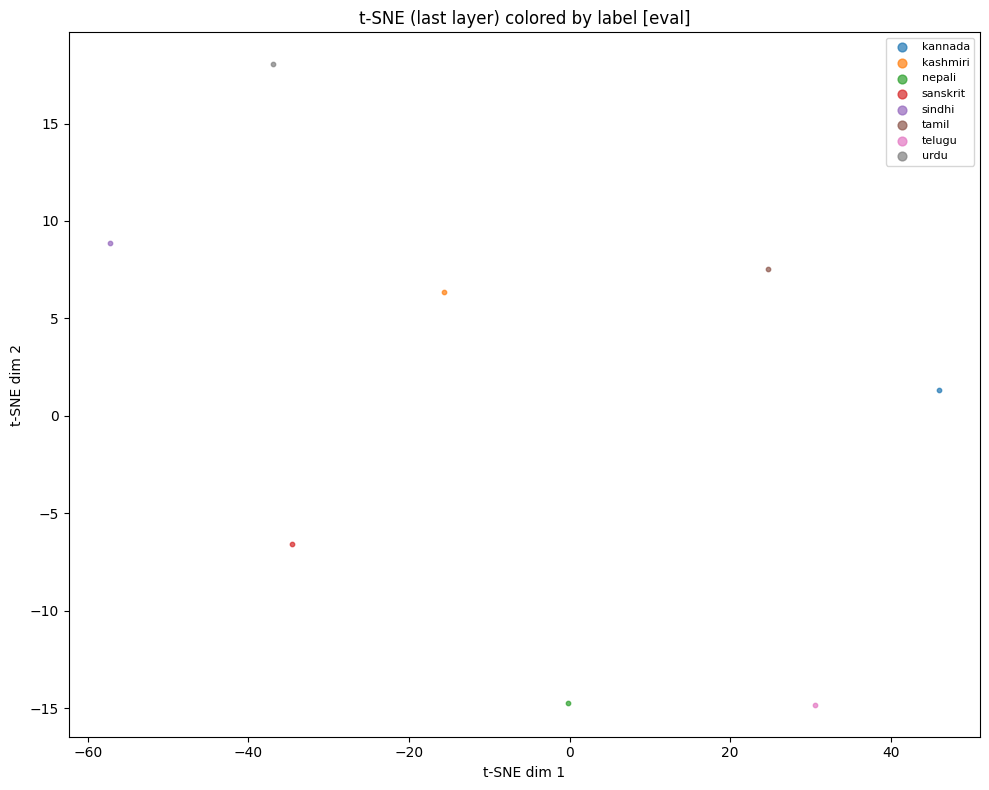

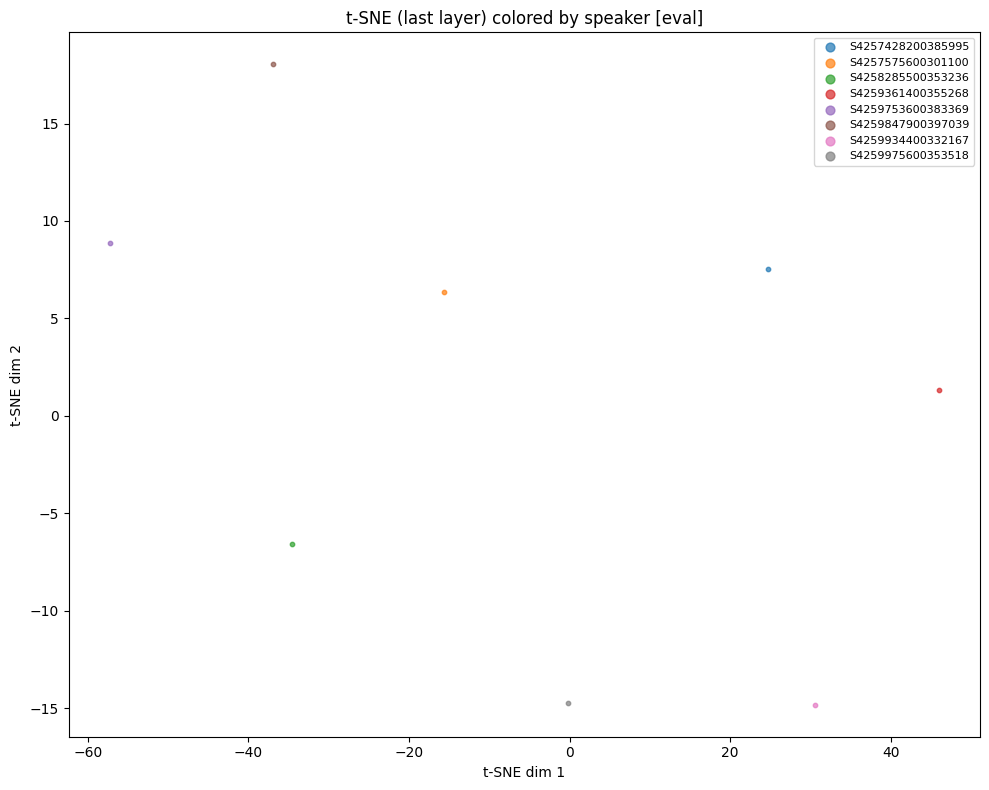

Saved to: /home/neuronet_team187/fati/indic-language-identification/outputs/models/tsne_analysis


,speaker_id,label,tsne_x,tsne_y
0,S4257428200385995,tamil,24.710070,7.557613
1,S4259934400332167,telugu,30.594046,-14.829427
2,S4259753600383369,sindhi,-57.249329,8.854817
3,S4259975600353518,nepali,-0.132334,-14.738572
4,S4258285500353236,sanskrit,-34.589115,-6.572773


In [36]:
df = pd.DataFrame(
    {
        "speaker_id": speakers,
        "label": labels,
        "tsne_x": X2[:, 0],
        "tsne_y": X2[:, 1],
    }
)
df.to_csv(output_dir / "metadata_tsne.csv", index=False)

plot_points(
    X2,
    labels,
    title=f"t-SNE (last layer) colored by label [{split}]",
    out_png=output_dir / "tsne_by_label.png",
)

plot_points(
    X2,
    speakers,
    title=f"t-SNE (last layer) colored by speaker [{split}]",
    out_png=output_dir / "tsne_by_speaker.png",
    max_legend_items=50,
)

print(f"Saved to: {output_dir.resolve()}")
display(df.head())